1. Installation and Libraries

In [472]:
pip install easyocr --user

  Using cached numpy-2.5.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
basemap 1.4.1 requires numpy<1.27,>=1.21; python_version >= "3.8", but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [474]:
pip install "numpy<2" --force-reinstall --user


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [1]:
#Packages and Libraries
from pdf2image import convert_from_path     #library that converts PDFs for redability
import pandas as pd                         #library that reads data files and creates/modifies datasets
import cv2                                  #image modification library                             
import matplotlib.pyplot as plt             #Visualizes data
import matplotlib.ticker as ticker          #modifies windows of visualizations 
import numpy as np                          #package for processesing and operating on numbers
import easyocr                              #Engine that reads images and creates strings/columns

2. MACRO Variables and Global Commands

In [4]:
# Initialize reader once
reader = easyocr.Reader(['en'], gpu=True)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [39]:
#Macro Variables for the processing of pages and files
filename = "Card_ID List_EN.pdf"                                         #Naming the PDF file containing cards
rangeE = [40, 60]                                                        #Naming 20 pages of the file being used for Energy Cards
rangeP = [60,1116]                                                       #Naming 1056 pages of the file being used for Pokemon Cards
rangep1 = [60,300]
rangep2 = [300,500]
rangep3 = [600,800]
rangep4 = [800, 1000]
rangep5 = [1000,1116]
rangeT = [1116, 1306]                                                    #Naming 191 pages of the file being used for Trainer Cards

In [8]:
#The following are coordinates of the textboxes containing data within each page of the file

#Card Boundaries confirmed using 'PokemonSmallTest'
#ymin = 0
#ymax = cards_dictionary["page_N"]["dimensions"][0]
#xmin = 0
#xmax = cards_dictionary["page_N"]["dimensions"][1]

#Subarrays within ENERGY CARDS containing information
#ymin, ymax, xmin, xmax pixel coordinates on minigrid: Check if format consistent on all energy cards
Textbox1a = [30, 60, 40, 250]    #Energy Type
Textbox2b = [30, 60, 350, 590]   #Card Type
Textbox3c = [70, 120, 40, 500]   #Card Name
Textbox4d = [797, 820, 65, 105]  #Expansion Code
Textbox5e = [809, 820, 110, 140] #Collector Number

Energy_Card_Format_Dictionary = { 
    "Energy Type": Textbox1a, "Card Type": Textbox2b, "Card Name": Textbox3c, 
    "Expansion Code": Textbox4d, "Collector No.": Textbox5e
                                }

#Subarrays within POKEMON CARDS containing information
#ymin, ymax, xmin, xmax pixel coordinates on minigrid: Check if format consistent on all pokemon cards
Textbox1 = [25, 50, 20, 100]     #Stage Textbox
Textbox2 = [30, 83, 120, 400]    #Card Name Textbox
Textbox3 = [30, 85, 450, 575]    #HP Textbox
Textbox4 = [80, 105, 115, 400]   #Evolves From Textbox
Textbox5 = [440, 730, 50, 580]   #Actions Textbox
Textbox6 = [725, 760, 35, 180]   #wekaness Textbox
Textbox7 = [725, 760, 190, 340]  #resistance Textbox       
Textbox8 = [725, 760, 370, 580]  #retreat Textbox          
Textbox9 = [800, 820, 70, 105]   #expansion code Textbox   
Textbox10 = [800, 830, 110, 140] #collector number Textbox
Textbox11 = [765, 787,28, 190]   #Illustrator

Pokemon_Card_Format_Dictionary = { 
    "Stage": Textbox1, "Card Name": Textbox2, "HP": Textbox3, "Evolves": Textbox4, 
    "Actions": Textbox5, "Weakness": Textbox6, "Resistance": Textbox7, 
    "Retreat": Textbox8, "Expansion": Textbox9, "Collector No.": Textbox10,
    "Illustrator": Textbox11
                                 }

#Subarrays within TRAINER CARDS containing information
#ymin, ymax, xmin, xmax pixel coordinates on minigrid: Check if format consistent on all energy cards
TextboxA = [30, 60, 40, 250]    #Trainer Type
TextboxB = [30, 60, 390, 590]   #Card Type
TextboxC = [70, 120, 40, 500]   #Card Name
TextboxD = [450, 740, 50, 570]  #Textbox
TextboxE = [750, 810, 230, 570] #Trainer Rule
TextboxF = [800, 820, 70, 105]  #Expansion Code
TextboxG = [810, 820, 110, 180] #Collector Number
TextboxH = [780, 792, 48, 160]  #Illustrator

Trainer_Card_Format_Dictionary = {
    "Trainer Type": TextboxA, "Card Type": TextboxB, "Card Name": TextboxC, 
    "Textbox": TextboxD, "Trainer Rule": TextboxE, "Expansion": TextboxF, 
    "Collector No.": TextboxG, "Illustrator": TextboxH
}

3. Functions

In [11]:
def LargePage_Crop(filename, Range):
    """Processes PDF pages 40-59, extracts rectangular images and saves arrays with dimensions to dictionary"""
    results = {}
    start = Range[0]
    end = Range[1]
    for N in range(start, end):  # Iterates from 40-60 for energy, 60-1116 for Pokemon, 1116-1307 for trainers
        try:
            # Convert PDF page to image
            img = convert_from_path(filename, first_page=N, last_page=N, dpi=200)
            card_arr = np.array(img[0])
            
            # Convert to grayscale for edge detection
            gray = cv2.cvtColor(card_arr, cv2.COLOR_RGB2GRAY)
            
            # Apply edge detection
            edges = cv2.Canny(gray, 50, 150)
            
            # Find contours
            contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            # Find the largest rectangular contour
            largest_area = 0
            best_contour = None
            
            for contour in contours:
                epsilon = 0.02 * cv2.arcLength(contour, True)
                approx = cv2.approxPolyDP(contour, epsilon, True)
                
                if len(approx) == 4:
                    area = cv2.contourArea(contour)
                    if area > largest_area:
                        largest_area = area
                        best_contour = contour
            
            # Get dimensions and crop if contour found
            if best_contour is not None:
                x, y, w, h = cv2.boundingRect(best_contour)
                cropped_card = card_arr[y:y+h, x:x+w]  # Crop the card region
                dimensions = [h, w, x, y]
            else:
                cropped_card = card_arr  # Use full page if no card found
                page_height, page_width, _ = card_arr.shape
                dimensions = [page_height, page_width, 0, 0]
            
            # Save to dictionary with page name and dimensions
            results[str(N)] = cropped_card
            #{
             #   'array': cropped_card,  # Array suitable for plt.imshow()
             #  'dimensions': dimensions  # [height, width, x, y]
            #}
            
        except Exception as e:
            print(f"Error processing page {N}: {e}")
            continue
    
    return results

In [13]:
def extract_card_subarrays(page_key, error_dict, format_dictionary):
    """using the coordinates of textboxes, this partitions pieces of the cropped cards
    and creates a dictionary with each subdivision or piece of card within page_N"""
    page_data = cards_dictionary[page_key]
    subarrays = {}
    
    for name, coords in format_dictionary.items():
        ymin, ymax, xmin, xmax = coords
        sliced_arr = page_data[ymin:ymax, xmin:xmax]
        
        # Check for empty slice error
        if sliced_arr.size == 0:
            if page_key not in error_dict:
                error_dict[page_key] = []
            error_dict[page_key].append((name, sliced_arr))
        else:
            subarrays[str(name)] = sliced_arr
            
    return subarrays


In [15]:
def process_page_range(rangep1, format_dict):
    """
    Extracts card subarrays for a given page range [start, end] (inclusive),
    filters out pages with errors, and prints diagnostic statistics.
    
    Args:
        rangep1 (list or tuple): A 2-element list/tuple [start, end].
        format_dict (dict): The dictionary containing formatting configurations.
        
    Returns:
        dict: Filtered dictionary of successfully processed page pieces.
    """
    error_list = {}

    # Build all_pieces via dictionary comprehension (range is end + 1 to include the last page)
    all_pieces = {
        str(N): extract_card_subarrays(str(N), error_list, format_dict)
        for N in range(rangep1[0], rangep1[1] + 1)
    }

    # Filter out pages that encountered coordinate slicing errors
    for bad_page in error_list:
        all_pieces.pop(bad_page, None)

    # Print diagnostic stats
    errors = sum(len(errs) for errs in error_list.values())
    print(f"The following pages are not predictably formatted and therefore cannot be included: {list(error_list.keys())}")
    print(f"Number of valid pages added to dictionary: {len(all_pieces)}")
    print(f"Total individual errors logged across bad pages: {errors}")

    return all_pieces

In [17]:
def _apply_scale_factor(contour: np.ndarray, scale_factor: int = 8) -> np.ndarray:
    """
    Applies a scale factor to improve contour readability.
    
    Args:
        contour: Input contour array
        scale_factor: Factor by which to scale the contour (default: 3)
        
    Returns:
        Scaled contour array
    """
    height, width = contour.shape[:2]
    scaled_contour = cv2.resize(
        contour, 
        (width * scale_factor, height * scale_factor), 
        interpolation=cv2.INTER_CUBIC
    )
    return scaled_contour

In [19]:
def extract_text_with_ocr(card_dict, reader_instance=reader):
    """
    Extracts text from a single card's image regions using EasyOCR.
    
    Parameters:
    - card_dict: Dictionary mapping field names to NumPy arrays (e.g., {'Stage': array, ...})
    - reader_instance: Initialized easyocr.Reader object
    
    Returns:
    - Dictionary mapping field names directly to extracted string text
    """
    extracted_strings = {}

    # Iterate through field name ("Stage", "Name", etc.) and image array
    for field_name, image_array in card_dict.items():
        ocr_result = reader_instance.readtext(
            image_array, 
            detail=0,
            width_ths=0.7,
            height_ths=0.7,  
            paragraph=True, 
            contrast_ths=0.1,   
            adjust_contrast=0.5 
        )
        
        # Combine lines if the region contains multiple lines/words
        clean_string = " ".join(ocr_result).strip() 
        extracted_strings[field_name] = clean_string if clean_string else "NA"

    return extracted_strings

In [21]:
def process_cards_recursive(dictionary, index=0):
    """
    Recursively iterates through each page in P_Card_dict and updates
    image arrays with extracted OCR strings.
    """
    page_keys = list(dictionary.keys())
    
    # Base case: stop when all pages are processed
    if index >= len(page_keys):
        return dictionary

    current_page_key = page_keys[index]
    current_card_images = dictionary[current_page_key]
    
    # Extract text with OCR
    extracted_text_dict = extract_text_with_ocr(current_card_images, reader_instance=reader)
    
    # Replace pixel arrays with extracted strings
    dictionary[current_page_key] = extracted_text_dict
    
    # Safely get 'Name' or fall back to the first available key if 'Name' is missing
    card_name = extracted_text_dict.get('Card Name')
    if card_name is None:
        # Fallback print if 'Name' slice was one of the missing error fields
        first_key = next(iter(extracted_text_dict.keys()), "Empty Card")
        card_name = f"[No 'Name' field - First key '{first_key}': '{extracted_text_dict.get(first_key)}']"

    print(f"Processed {current_page_key}: {card_name}")

    # Recursive step
    return process_cards_recursive(dictionary, index + 1)

4. Function Call

In [24]:
#Cropping White PDF Page to include only the card image, then creating a list of scaled images
#Called Card_Set. In this call and the subsequent images shown below, 4 errors are found.                                                            

cards_dictionary = LargePage_Crop(filename,[40,1307])

4A. Creating Pokemon Card Dictionary by Extracting information from PDF

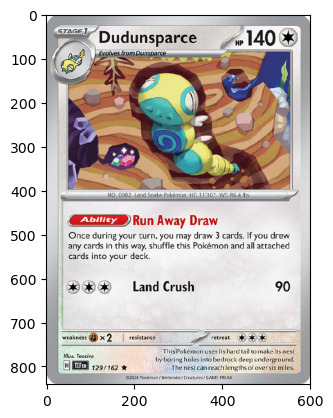

In [29]:
#Visualizing results
plt.imshow(cards_dictionary["105"]) #error on Card_Set[3], Card_Set[8], Card_Set[16], Card_Set[19]
                                  #Low Priority, these errors could replicate missing cards in a full
                                  #collected deck when in game play.

In [26]:
all_pieces1 = process_page_range(rangep1, Pokemon_Card_Format_Dictionary)

The following pages are not predictably formatted and therefore cannot be included: ['63', '68', '69', '76', '79', '83', '85', '91', '102', '114', '118', '119', '122', '123', '135', '138', '146', '147', '156', '160', '164', '169', '177', '178', '179', '180', '189', '192', '193', '200', '215', '218', '223', '228', '229', '232', '237', '244', '246', '249', '262', '268', '270', '271', '275', '278', '280', '282', '283', '285', '287', '288', '298']
Number of valid pages added to dictionary: 188
Total individual errors logged across bad pages: 469


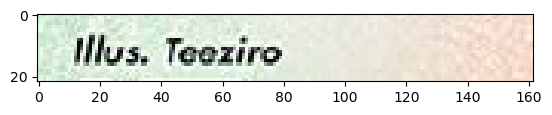

In [146]:
plt.imshow(all_pieces1['105']['Illustrator'])

In [28]:
# Apply scale factor (scale = 8) to every array across all pages
P_Card_dict = {
    page_key: {
        textbox: _apply_scale_factor(arr, 8)
        for textbox, arr in sub_dict.items()
    }
    for page_key, sub_dict in all_pieces1.items()
}

<class 'numpy.ndarray'>


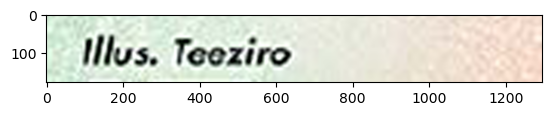

In [150]:
# Access a scaled NumPy array directly by key
scaled_stage = P_Card_dict["105"]["Illustrator"]

# Check shape/type
print(type(scaled_stage))  # <class 'numpy.ndarray'>
plt.imshow(scaled_stage)

In [30]:
#Extract information and create datatypes Batch 1
all_processed_cards1 = process_cards_recursive(P_Card_dict,0)
P_df1 = pd.DataFrame.from_dict(all_processed_cards1, orient='index')
P1 = P_df1.reset_index().rename(columns={'index': 'Card ID'})
P1.head()

C:\Users\cabla\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processed 60: Scrafty
Processed 61: Hippopotas
Processed 62: Hippowdon
Processed 64: Pinsir
Processed 65: Leafeon
Processed 66: Iron Leaves
Processed 67: Poltchageist
Processed 70: Chi-Yu
Processed 71: Glaceon
Processed 72: Froakie
Processed 73: Frogadier
Processed 74: Walking Wake
Processed 75: Morpeko
Processed 77: Girafarig
Processed 78: Enamorus
Processed 80: Ting-Lu
Processed 81: Applin
Processed 82: Eevee
Processed 84: Shaymin
Processed 86: Totodile
Processed 87: Croconaw
Processed 88: Feraligatr
Processed 89: Wiglett
Processed 90: Palafin
Processed 92: Marill
Processed 93: Bronzor
Processed 94: Bronzong
Processed 95: Flutter Mane
Processed 96: Relicanth
Processed 97: Great Tusk
Processed 98: Gastly
Processed 99: Haunter
Processed 100: Roariig Moom
Processed 101: Koraidon
Processed 103: Hoothoot
Processed 104: Dunsparce
Processed 105: Dudunsparce
Processed 106: Pineco
Processed 107: Seedot
Processed 108: Nuzleaf
Processed 109: Shiftry
Processed 110: Deerling
Processed 111: Sawsbu

,Card ID,Stage,Card Name,HP,Evolves,Actions,Weakness,Resistance,Retreat,Expansion,Collector No.,Illustrator
0,60,STAGEU,Scrafty,120,Evolves from Scraggy,Nab 'n' Dash Search your deck for a number of ...,wcakncss x2,resistanec,retrcat,Ut,88,Illos . OKUBO
1,61,BASIG,Hippopotas,90 4 HP,NA,Push Down 10 Switch out your opponent's Active...,weakness x2,resistance,retreat,McM,05/,Illus. Minohamu
2,62,StAGE],Hippowdon,160 4,Evolves from Hippopotas,4 Ram 60 Super Sandstorm 150 This attack also ...,weakness x2,resistance,retreat,McM,06/,Illus. Minohamu
3,64,BASIG,Pinsir,) 110,NA,Slow Crunch Discard all Energy from this Pokem...,weakness x2,resistance,retreat,L,03 /,Illus. HYOGONOSUKE
4,65,STAGE],Leafeon,120,Evolves from Eevee,Leaflet Blessings Attach a Basic Energy card f...,weakness x2,resistance,retreat,L,11/,Illus. Kuroimori


In [32]:
P1.to_excel('P1.xlsx', index=False) #Exported

In [28]:
#Batch 2

#Crops textboxes from Cards
all_pieces2 = process_page_range(rangep2, Pokemon_Card_Format_Dictionary)         

# Apply scale factor (scale = 8) to every array across all pages
P_Card_dict2 = {
    page_key: {
        textbox: _apply_scale_factor(arr, 8)
        for textbox, arr in sub_dict.items()
    }
    for page_key, sub_dict in all_pieces2.items()
}

#Extracts text from the cropped boxes
all_processed_cards2 = process_cards_recursive(P_Card_dict2,0)

#Creates DataFrame composed of all extracted strings
P_df2 = pd.DataFrame.from_dict(all_processed_cards2, orient='index')
P2 = P_df2.reset_index().rename(columns={'index': 'Card ID'})

P2.to_excel('P2.xlsx', index=False)

The following pages are not predictably formatted and therefore cannot be included: ['304', '305', '307', '308', '309', '310', '311', '322', '332', '338', '341', '345', '352', '355', '359', '365', '367', '368', '370', '375', '376', '379', '380', '381', '396', '398', '399', '400', '401', '402', '403', '404', '405', '408', '411', '418', '419', '420', '426', '428', '443', '446', '463', '470', '486', '494', '497']
Number of valid pages added to dictionary: 154
Total individual errors logged across bad pages: 443


C:\Users\cabla\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processed 300: Lombre
Processed 301: Ludicolo
Processed 302: Wailmer
Processed 303: Wailord
Processed 306: N's Joltik
Processed 312: Banette
Processed 313: Beldum
Processed 314: Metang
Processed 315: Metagross
Processed 316: N's Sigilyph
Processed 317: Lillie  5 Cutiefly
Processed 318: Lillie's Ribombee
Processed 319: Lillie  5 Comfey
Processed 320: Swinub
Processed 321: Piloswine
Processed 323: Larvitar
Processed 324: Pupitar
Processed 325: Rockruff
Processed 326: Lycanroc
Processed 327: Hop's Silicobra
Processed 328: Hop's Sandaconda
Processed 329: Tyranitar
Processed 330: Ns Purrloin
Processed 331: N's Zorua
Processed 333: Ns Klink
Processed 334: N's Klang
Processed 335: N's Klinklang
Processed 336: Magearna
Processed 337: Hop's Corviknight
Processed 339: Bagon
Processed 340: Shelgon
Processed 342: Ns Reshiram
Processed 343: Hop's Snorlax
Processed 344: Dunsparce
Processed 346: Hop's Rookidee
Processed 347: Hop's Corvisquire
Processed 348: Hop's Wooloo
Processed 349: Hop's Dubwool
P

In [27]:
#Batch 3

#Crops textboxes from Cards
all_pieces3 = process_page_range(rangep3, Pokemon_Card_Format_Dictionary)          

# Apply scale factor (scale = 8) to every array across all pages
P_Card_dict3 = {
    page_key: {
        textbox: _apply_scale_factor(arr, 8)
        for textbox, arr in sub_dict.items()
    }
    for page_key, sub_dict in all_pieces3.items()
}

#Extracts text from the cropped boxes
all_processed_cards3 = process_cards_recursive(P_Card_dict3,0)

#Creates pandas DataFrame composed of all extracted strings
P_df3 = pd.DataFrame.from_dict(all_processed_cards3, orient='index')
P3 = P_df3.reset_index().rename(columns={'index': 'Card ID'})
P3.to_excel('P3.xlsx', index=False)

The following pages are not predictably formatted and therefore cannot be included: ['600', '612', '622', '637', '657', '670', '680', '687', '691', '701', '717', '726', '734', '762', '776', '786', '793', '795']
Number of valid pages added to dictionary: 183
Total individual errors logged across bad pages: 172


C:\Users\cabla\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processed 601: Deerling
Processed 602: Sawsbuck
Processed 603: Shelmet
Processed 604: Accelgor
Processed 605: Virizion
Processed 606: Tepig
Processed 607: Pignite
Processed 608: Emboar
Processed 609: Pansear
Processed 610: Simisear
Processed 611: Heatmor
Processed 613: Oshawott
Processed 614: Dewott
Processed 615: Samurott
Processed 616: Basculin
Processed 617: Ducklett
Processed 618: Swanna
Processed 619: Vanillite
Processed 620: Vanillish
Processed 621: Vanilluxe
Processed 623: Blitzle
Processed 624: Zebstrika
Processed 625: loltik
Processed 626: Galvantula
Processed 627: Stunfisk
Processed 628: Woobat
Processed 629: Swoobat
Processed 630: Sigilyph
Processed 631: Yamask
Processed 632: Cofagrigus
Processed 633: Gothita
Processed 634: Gothorita
Processed 635: Gothitelle
Processed 636: Frillish
Processed 638: Roggenrola
Processed 639: Boldore
Processed 640: Gigalith
Processed 641: Sawk
Processed 642: Archen
Processed 643: Archeops
Processed 644: Mienfoo
Processed 645: Mienshao
Processed

In [26]:
#Batch 4

#Crops textboxes from Cards
all_pieces4 = process_page_range(rangep4, Pokemon_Card_Format_Dictionary)         

# Apply scale factor (scale = 8) to every array across all pages
P_Card_dict4 = {
    page_key: {
        textbox: _apply_scale_factor(arr, 8)
        for textbox, arr in sub_dict.items()
    }
    for page_key, sub_dict in all_pieces4.items()
}

#Extracts text from the cropped boxes
all_processed_cards4 = process_cards_recursive(P_Card_dict4,0)

#Creates pandas DataFrame composed of all extracted strings
P_df4 = pd.DataFrame.from_dict(all_processed_cards4, orient='index')
P4 = P_df4.reset_index().rename(columns={'index': 'Card ID'})

P4.to_excel('P4.xlsx', index=False)

The following pages are not predictably formatted and therefore cannot be included: ['805', '811', '820', '829', '834', '845', '867', '874', '888', '900', '907', '925', '935', '943', '950', '958', '967', '971', '978', '983', '990', '993', '996']
Number of valid pages added to dictionary: 178
Total individual errors logged across bad pages: 207


C:\Users\cabla\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processed 800: Bewear
Processed 801: Snubbull
Processed 802: Granbull
Processed 803: Cresselia
Processed 804: Meloetta
Processed 806: Mimikyu
Processed 807: Milcery
Processed 808: Alcremie
Processed 809: Gastly
Processed 810: Haunter
Processed 812: Murkrow
Processed 813: Honchkrow
Processed 814: Sableye
Processed 815: Absol
Processed 816: Eternatus
Processed 817: Oddish
Processed 818: Gloom
Processed 819: Vileplume
Processed 821: Lotad
Processed 822: Lombre
Processed 823: Ludicolo
Processed 824: Genesect
Processed 825: Nymble
Processed 826: Lokix
Processed 827: Charmander
Processed 828: Charmeleon
Processed 830: Moltres
Processed 831: Darumaka
Processed 832: Darmanitan
Processed 833: Reshiram
Processed 835: Charcadet
Processed 836: Ceruledge
Processed 837: Seel
Processed 838: Dewgong
Processed 839: Swinub
Processed 840: Piloswine
Processed 841: Mamoswine
Processed 842: Suicune
Processed 843: Piplup
Processed 844: Prinplup
Processed 846: Yamper
Processed 847: Boltund
Processed 848: Pawm

In [26]:
#Batch 5

#Crops textboxes from Cards
all_pieces5 = process_page_range(rangep5, Pokemon_Card_Format_Dictionary)     

# Apply scale factor (scale = 8) to every array across all pages
P_Card_dict5 = {
    page_key: {
        textbox: _apply_scale_factor(arr, 8)
        for textbox, arr in sub_dict.items()
    }
    for page_key, sub_dict in all_pieces5.items()
}

#Extracts text from the cropped boxes
all_processed_cards5 = process_cards_recursive(P_Card_dict5,0)

#Creates pandas DataFrame composed of all extracted strings
P_df5 = pd.DataFrame.from_dict(all_processed_cards5, orient='index')
P5 = P_df5.reset_index().rename(columns={'index': 'Card ID'})



The following pages are not predictably formatted and therefore cannot be included: ['1001', '1007', '1008', '1014', '1018', '1023', '1027', '1029', '1032', '1036', '1041', '1045', '1061', '1065', '1070', '1079', '1095', '1101', '1103', '1110']
Number of valid pages added to dictionary: 97
Total individual errors logged across bad pages: 189


C:\Users\cabla\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processed 1000: Marill
Processed 1002: Shuppet
Processed 1003: Beheeyem
Processed 1004: Swirlix
Processed 1005: Slurpuff
Processed 1006: Fidough
Processed 1009: Fezandipiti
Processed 1010: Iron Boulder
Processed 1011: Hitmontop
Processed 1012: Groudon
Processed 1013: Riolu
Processed 1015: Carbink
Processed 1016: Crabrawler
Processed 1017: Passimian
Processed 1019: Venipede
Processed 1020: Whirlipede
Processed 1021: Scolipede
Processed 1022: Vullaby
Processed 1024: Hoopa
Processed 1025: Brute Bonnet
Processed 1026: Mawile
Processed 1028: Bronzor
Processed 1030: Melmetal
Processed 1031: Duraludon
Processed 1033: Fraxure
Processed 1034: Haxorus
Processed 1035: Larrys Dunsparce
Processed 1037: Slakoth
Processed 1038: Vigoroth
Processed 1039: Skitty
Processed 1040: Delcatty
Processed 1042: Larry's Starly
Processed 1043: Larry's Staravia
Processed 1044: Larry's Staraptor
Processed 1046: Larry's Rufflet
Processed 1047: Larrys Braviary
Processed 1048: Larry's Komala
Processed 1049: Drampa
Proc

In [33]:
P5.to_excel('output.xlsx', index=False)

,Card ID,Stage,Card Name,HP,Evolves,Actions,Weakness,Resistance,Retreat,Expansion,Collector No.,Illustrator
0,1000,BASIG,Marill,70 HP,NA,"Hide FFlip a coin. If heads, during your oppon...",weakness 6 x2,resistance,retreat,Jan,83/,Illus. Yoshimoto Yoshimon
1,1002,BASIG,Shuppet,60 HP,NA,Spooky Shot 20,weakness x2,resistance E ~30,retreat,Jan,90 /,Illus: miki kudo
2,1003,StAGGU,Beheeyem,100,Evolves from Elgyem,Cosmic Beatdown 20x This attack does 20 damage...,weakness x2,resistance -30,retreat,Eu,74/,Illus. Shinya Komatsu
3,1004,BASIG,Swirlix,60 HP,NA,Ram 20,weakness 6 x2,resistance,retreat,Jan,93/,Illus. Sayo Tsurula
4,1005,StAGE],Slurpuff,120,Evolves from Swirlix,Tackle 40 Magical Shot 70,weakness & x2,resistance,retreat,Jan,94/ _,Illus. Natsumi Yoshida
...,...,...,...,...,...,...,...,...,...,...,...,...
92,1112,BASIG,Bunnelby,HP 70,NA,Smash Kick 10,weakness x2,resiseance,retreae,Jt,64/,Illus . MINAHINAMI Take
93,1113,STAGEI,Diggersby,150,Evolves from Bunnelby,Earthquake 140 This attack also does 30 damage...,weakness x2,resiseance,retrele,Jt,65/,Illus . Mousho
94,1114,BASIG,Fletchling,Hp 60,NA,Chirp Search your deck for up t0 2 Pokemon wit...,weakness x2,resistance -30,retreae,Jt,66/,Illus. jowsoty
95,1115,BASIG,Furfrou,HP 90,NA,Hand Trim Discard random cards from your oppon...,weakness x2,resiseance,retreae,Jt,67 /,Illus . Teuzlto


4B. Energy Cards Function Call

The following pages are not predictably formatted and therefore cannot be included: []
Number of valid pages added to dictionary: 21
Total individual errors logged across bad pages: 0


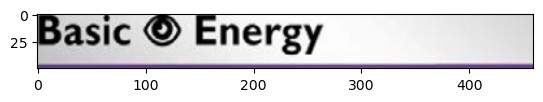

In [29]:
#Crops textboxes from Cards
all_pieces6 = process_page_range(rangeE, Energy_Card_Format_Dictionary) 

#Testing Dimensions with visuals
plt.imshow(all_pieces6['44']['Card Name'])

In [31]:
# Apply scale factor (scale = 8) to every array across all pages
E_Card_dict = {
    page_key: {
        textbox: _apply_scale_factor(arr, 8)
        for textbox, arr in sub_dict.items()
    }
    for page_key, sub_dict in all_pieces6.items()
}

#Extracts text from the cropped boxes
all_processed_cards6 = process_cards_recursive(E_Card_dict,0)

C:\Users\cabla\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processed 40: Basic Energy
Processed 41: Basic @ Energy
Processed 42: Basic 2 Energy
Processed 43: Basic Energy
Processed 44: Basic Energy
Processed 45: Basic # Energy
Processed 46: Basic @ Energy
Processed 47: Basic v Energy
Processed 48: Boomerang Energy
Processed 49: Neo Upper Energy
Processed 50: Mist Energy
Processed 51: Legacy Energy
Processed 52: Enriching Energy
Processed 53: Spiky Energy
Processed 54: Team Rocket' s Energy
Processed 55: Prism Energy
Processed 56: Ignition Energy
Processed 57: Growing Energy
Processed 58: Telepathic Energy
Processed 59: Rocky 4 Energy
Processed 60: Evolves Irom Scraggy


In [33]:
#Creates pandas DataFrame composed of all extracted strings
E_df = pd.DataFrame.from_dict(all_processed_cards6, orient='index')
E = E_df.reset_index().rename(columns={'index': 'Card ID'})

In [35]:
E.to_excel('E.xlsx', index=False)

4C. Trainer Cards

The following pages are not predictably formatted and therefore cannot be included: []
Number of valid pages added to dictionary: 191
Total individual errors logged across bad pages: 0


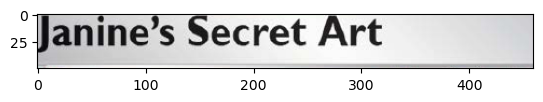

In [41]:
#Crops textboxes from Cards
all_pieces7 = process_page_range(rangeT, Trainer_Card_Format_Dictionary) 

#Testing Dimensions with visuals
plt.imshow(all_pieces7['1234']['Card Name'])

In [43]:
# Apply scale factor (scale = 8) to every array across all pages
T_Card_dict = {
    page_key: {
        textbox: _apply_scale_factor(arr, 8)
        for textbox, arr in sub_dict.items()
    }
    for page_key, sub_dict in all_pieces7.items()
}

#Extracts text from the cropped boxes
all_processed_cards7 = process_cards_recursive(T_Card_dict,0)

C:\Users\cabla\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processed 1116: Roto-Stick
Processed 1117: Hole-Digging Shovel
Processed 1118: Rare Candy
Processed 1119: Unfair Stamp
Processed 1120: Enhanced Hammer
Processed 1121: Hyper Aroma
Processed 1122: Love Ball
Processed 1123: Boxed Order
Processed 1124: Awakening Drum
Processed 1125: Buddy-Buddy Poffin
Processed 1126: Hand Trimmer
Processed 1127: Prime Catcher
Processed 1128: Reboot Pod
Processed 1129: Ogre's Mask
Processed 1130: Accompanying Flute
Processed 1131: Secret Box
Processed 1132: Scoop Up Cyclone
Processed 1133: Bug Catching Set
Processed 1134: Dangerous Laser
Processed 1135: Poke Vital A
Processed 1136: Night Stretcher
Processed 1137: Glass Trumpet
Processed 1138: Antique Root Fossil H
Processed 1139: Energy Search Pro
Processed 1140: Call Bell
Processed 1141: Dusk Ball
Processed 1142: Meddling Memo
Processed 1143: Megaton Blower
Processed 1144: Dragon Elixir
Processed 1145: Deduction Kit
Processed 1146: Scramble Switch
Processed 1147: Chill Teaser Toy
Processed 1148: Miracle He

In [44]:
#Creates pandas DataFrame composed of all extracted strings
T_df = pd.DataFrame.from_dict(all_processed_cards7, orient='index')
T = T_df.reset_index().rename(columns={'index': 'Card ID'})
T.to_excel('T.xlsx', index=False)